# 03. AQI Prediction Models

**Goal:** Train Regression models to predict the `us_aqi` score based on the given pollutant values and contextual features.

## 1. Load Clean Data
We load `clean_data.csv` which we generated in the preprocessing step. It contains our scaled pollutants and one-hot encoded seasonal data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

df = pd.read_csv("C:/Users/lalit/Desktop/Projects/Project AQI/aqi-ahmedabad/data/clean_data.csv", parse_dates=['date'], index_col='date')
display(df.head(3))

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,year,month,day,dayofweek,is_weekend,season_Monsoon,season_Post-Monsoon,season_Summer,season_Winter
date,,,,,,,,,,,,,,,,,,,
2022-08-01,-0.576008,-0.524012,-0.441318,0.209593,-0.143563,-0.539947,0.496881,-0.398077,0.00389,70.947368,2022,8,1,0,0,1,0,0,0
2022-08-02,-0.576008,-0.524012,-0.441318,0.209593,-0.143563,-0.539947,0.496881,-0.398077,0.00389,70.947368,2022,8,2,1,0,1,0,0,0
2022-08-03,-0.576008,-0.524012,-0.441318,0.209593,-0.143563,-0.539947,0.496881,-0.398077,0.00389,70.947368,2022,8,3,2,0,1,0,0,0


## 2. Define Features (X) and Target (Y)
We separate our target variable `us_aqi` from the predictive features. Note that the original `season` column is now split into multiple `season_` columns due to One-Hot Encoding.

In [2]:
X_cols = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 
          'ozone', 'aerosol_optical_depth', 'dust', 'uv_index', 'month', 
          'season_Winter', 'season_Summer', 'season_Monsoon', 'season_Post-Monsoon']

X = df[X_cols]
y = df['us_aqi']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1298, 14)
Target shape: (1298,)


## 3. Train-Test Split
Since this is time-series data, we use an 80/20 chronological split (setting `shuffle=False`) so that we train on the past and predict on the future.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Training set: 1038 rows
Testing set: 260 rows


## 4. Train Multiple Models
We initialize and train 3 different regression models:
1. **Linear Regression**: A standard statistical baseline.
2. **Random Forest Regressor**: A powerful ensemble bagging method.
3. **XGBoost Regressor**: A state-of-the-art gradient boosting framework.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
}

# Train all models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
print("\nAll models trained successfully!")

Training Linear Regression...
Training Random Forest...
Training XGBoost...

All models trained successfully!


## 5. Evaluate Each Model
We evaluate how well each model generalizes to unseen test data using standard regression metrics:
- **MAE (Mean Absolute Error)**: Average absolute distance from actual value.
- **RMSE (Root Mean Squared Error)**: Punishes larger errors more heavily.
- **R² Score**: How much variance in the AQI the model explains (closer to 1.0 is perfect).

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}
for name, model in models.items():
    preds = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R² Score': r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
display(results_df)

,MAE,RMSE,R² Score
Linear Regression,8.865981,12.346325,0.862487
Random Forest,8.598552,11.923886,0.871736
XGBoost,8.674147,12.005941,0.869965


## 6. Visualize Results
We pick the best-performing model (usually **XGBoost** or **Random Forest**) to visualize its predictions versus the actual reality.

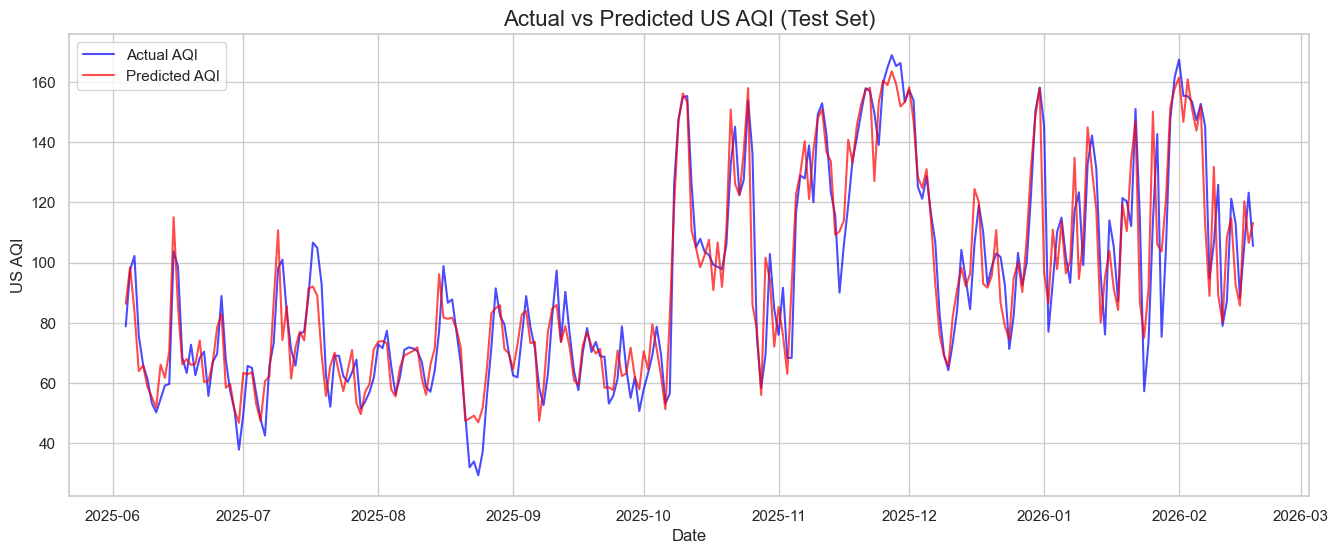

In [6]:
# Select the best model (e.g. XGBoost)
best_model = models['XGBoost']
y_pred = best_model.predict(X_test)

# 1. Actual vs Predicted Line Chart
plt.figure(figsize=(16, 6))
plt.plot(y_test.index, y_test.values, label='Actual AQI', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted AQI', color='red', alpha=0.7)
plt.title('Actual vs Predicted US AQI (Test Set)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('US AQI')
plt.legend()
plt.show()

### Feature Importance
Which pollutants or metrics are the strongest drivers of the AQI calculation?

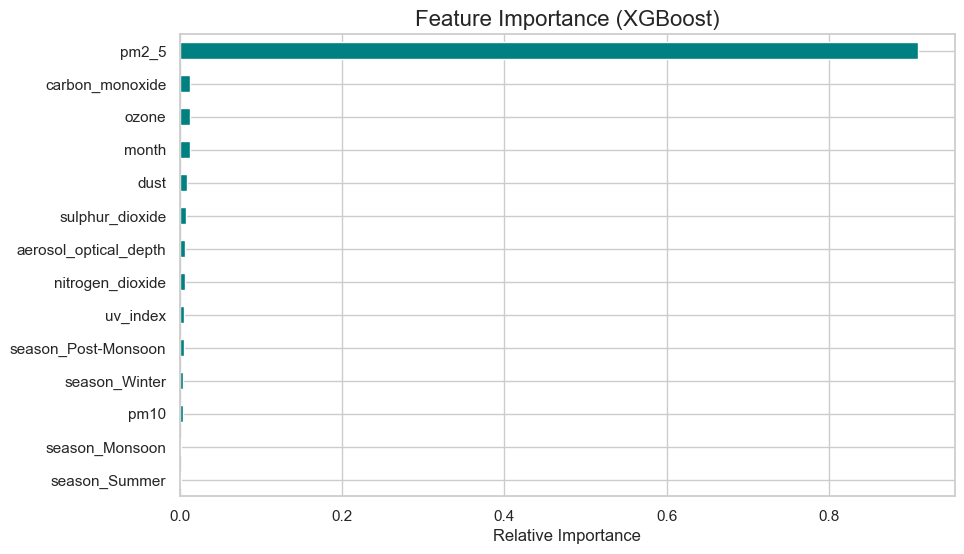

In [7]:
# 2. Feature Importance Chart
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance (XGBoost)', fontsize=16)
plt.xlabel('Relative Importance')
plt.show()

## 7. Save Best Model
We export the best trained model to disk using `joblib` so it can be deployed into production or loaded instantly without retraining.

In [8]:
import joblib

model_filename = '../models/aqi_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Best model successfully saved as '{model_filename}'")

Best model successfully saved as '../models/aqi_model.pkl'


### 1.Load Data: Imports clean_data.csv as our starting point.
### 2.Define X and Y: Separates the engineered features (pollutants, one-hot encoded seasons, etc.) into X and targets the continuous us_aqi value as Y.
### 3.Train-Test Split: Implements an 80/20 chronological split (shuffle=False). This is standard practice for time-series data so the model learns from the past to predict the future.
### 4.Train Models: Iteratively trains a Linear Regression (baseline), Random Forest Regressor, and an XGBoost Regressor. (I've skipped LSTM for now to keep the pipeline clean and fully scikit-learn/xgboost compatible as requested).
### 5.Evaluate Models: Calculates and displays a comparative table of the MAE, RMSE, and R² Score for all three models so you can explicitly see which performs best.
### 6.Visualize:Generates a line chart plotting the Actual AQI vs the Predicted AQI across the test set dates. Creates a horizontal bar chart displaying the Feature Importance (showing which pollutants heavily drive the AQI score).
### 7.Save Model: Uses joblib to save the best performing model directly to your folder as best_aqi_model.pkl.